In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math, ast
import plotly.express as px
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../../Dataset/target.csv')
#df = pd.concat([df, pd.read_csv('../../Dataset/glauco.csv')], axis=0)
#df = pd.concat([df, pd.read_csv('../../Dataset/pasta.csv')], axis=0)

df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   data     836 non-null    object
 1   alcohol  836 non-null    object
dtypes: object(2)
memory usage: 13.2+ KB


,data,alcohol
0,"[23534, 24013, 26216, 26172, 26108, 25037, 240...",False
1,"[23797, 24164, 26134, 26143, 26142, 26120, 253...",False
2,"[23899, 24905, 26249, 26359, 26335, 26225, 254...",False
3,"[23967, 24384, 26285, 26237, 26228, 26188, 261...",False
4,"[23859, 24287, 26269, 26188, 26115, 25477, 245...",False
...,...,...
831,"[17287,18389,22034,22425,22695,20875,19088,182...",False
832,"[18351,19368,22078,20484,19383,18829,18536,183...",False
833,"[19361,20316,23101,22295,20981,20080,19565,192...",False
834,"[18273,19296,22168,21370,19968,19125,18633,184...",False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   data     836 non-null    object
 1   alcohol  836 non-null    object
dtypes: object(2)
memory usage: 13.2+ KB


# VISUALIZAÇÃO DOS DADOS

In [4]:
df.describe()

,data,alcohol
count,836,836
unique,828,6
top,"[14736,16107,20573,20583,20539,20323,20389,203...",True
freq,2,283


In [5]:
df['alcohol'] = df.alcohol.apply(ast.literal_eval)
df['data']    = df.data.apply(ast.literal_eval)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   data     836 non-null    object
 1   alcohol  836 non-null    bool  
dtypes: bool(1), object(1)
memory usage: 7.5+ KB


,data,alcohol
0,"[23534, 24013, 26216, 26172, 26108, 25037, 240...",False
1,"[23797, 24164, 26134, 26143, 26142, 26120, 253...",False
2,"[23899, 24905, 26249, 26359, 26335, 26225, 254...",False
3,"[23967, 24384, 26285, 26237, 26228, 26188, 261...",False
4,"[23859, 24287, 26269, 26188, 26115, 25477, 245...",False
...,...,...
831,"[17287, 18389, 22034, 22425, 22695, 20875, 190...",False
832,"[18351, 19368, 22078, 20484, 19383, 18829, 185...",False
833,"[19361, 20316, 23101, 22295, 20981, 20080, 195...",False
834,"[18273, 19296, 22168, 21370, 19968, 19125, 186...",False


### VALORES ÚNICOS

In [6]:
def showUnique(df):
    w = max(len(c) for c in df.columns)  # largura do maior nome de coluna

    for col in df.columns:
        try:
            unique = df[col].unique().tolist()
            N      = len(unique)
            exemplo = ', '.join(map(str, unique[:10]))
            print(f'{col:<{w}}  [{exemplo}{f" ... +{len(unique)}" if N > 10 else ""}]')
        except Exception as error:
            print(error)    

showUnique(df)

unhashable type: 'list'
alcohol  [False, True]


- Variável Alvo, verificação de desbalanceamento

In [7]:
TARGET = 'alcohol'

for label in df[TARGET].unique():
    total = (df[TARGET] == label).sum()
    print(f'classe {label}: {(total)} ({total/len(df)*100:.2f}%)')

classe False: 415 (49.64%)
classe True: 421 (50.36%)


### COLUNAS INVÁLIDAS

In [8]:
nan_rows = df[df.isna().any(axis=1)]
print(len(nan_rows), 'colunas NaN')
nan_rows

0 colunas NaN


,data,alcohol


### LINHAS INVÁLIDAS

In [9]:
nan_columns = df.columns[df.isna().any()].tolist()

for column in nan_columns:
    N = df[column].isna().sum()
    print(f'"{column}": {N} NaN rows ({N/len(df)*100:.2f}%)')

# VERIFICAÇÃO DE INTEGRIDADE

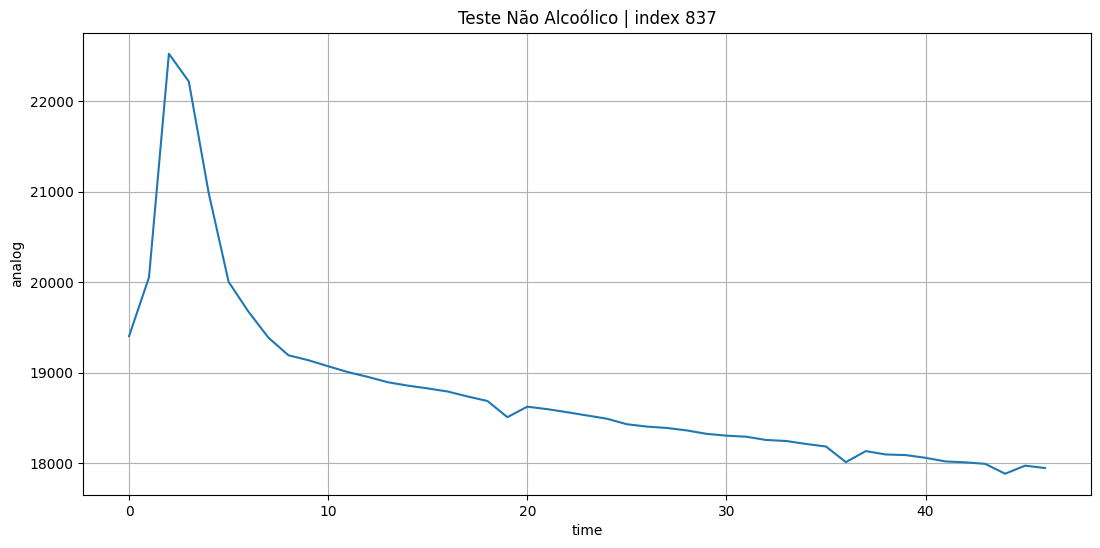

In [10]:
def plotAlcohol(data, alcohol):
    plt.plot(data)
    plt.title(f'Teste {"Alcoólico" if alcohol else "Não Alcoólico"}' + f' | index {(len(df) + 1) if index < 0 else index}')
    plt.grid(), plt.xlabel('time'), plt.ylabel('analog');


plt.figure(figsize=(13, 6))
index = -1
plotAlcohol(df.iloc[index].data, df.iloc[index].alcohol)

In [11]:
sum([len(data) == 47 for data in df.data]) == len(df)

True

# VISUALIZAÇÃO MÚLTIPLA

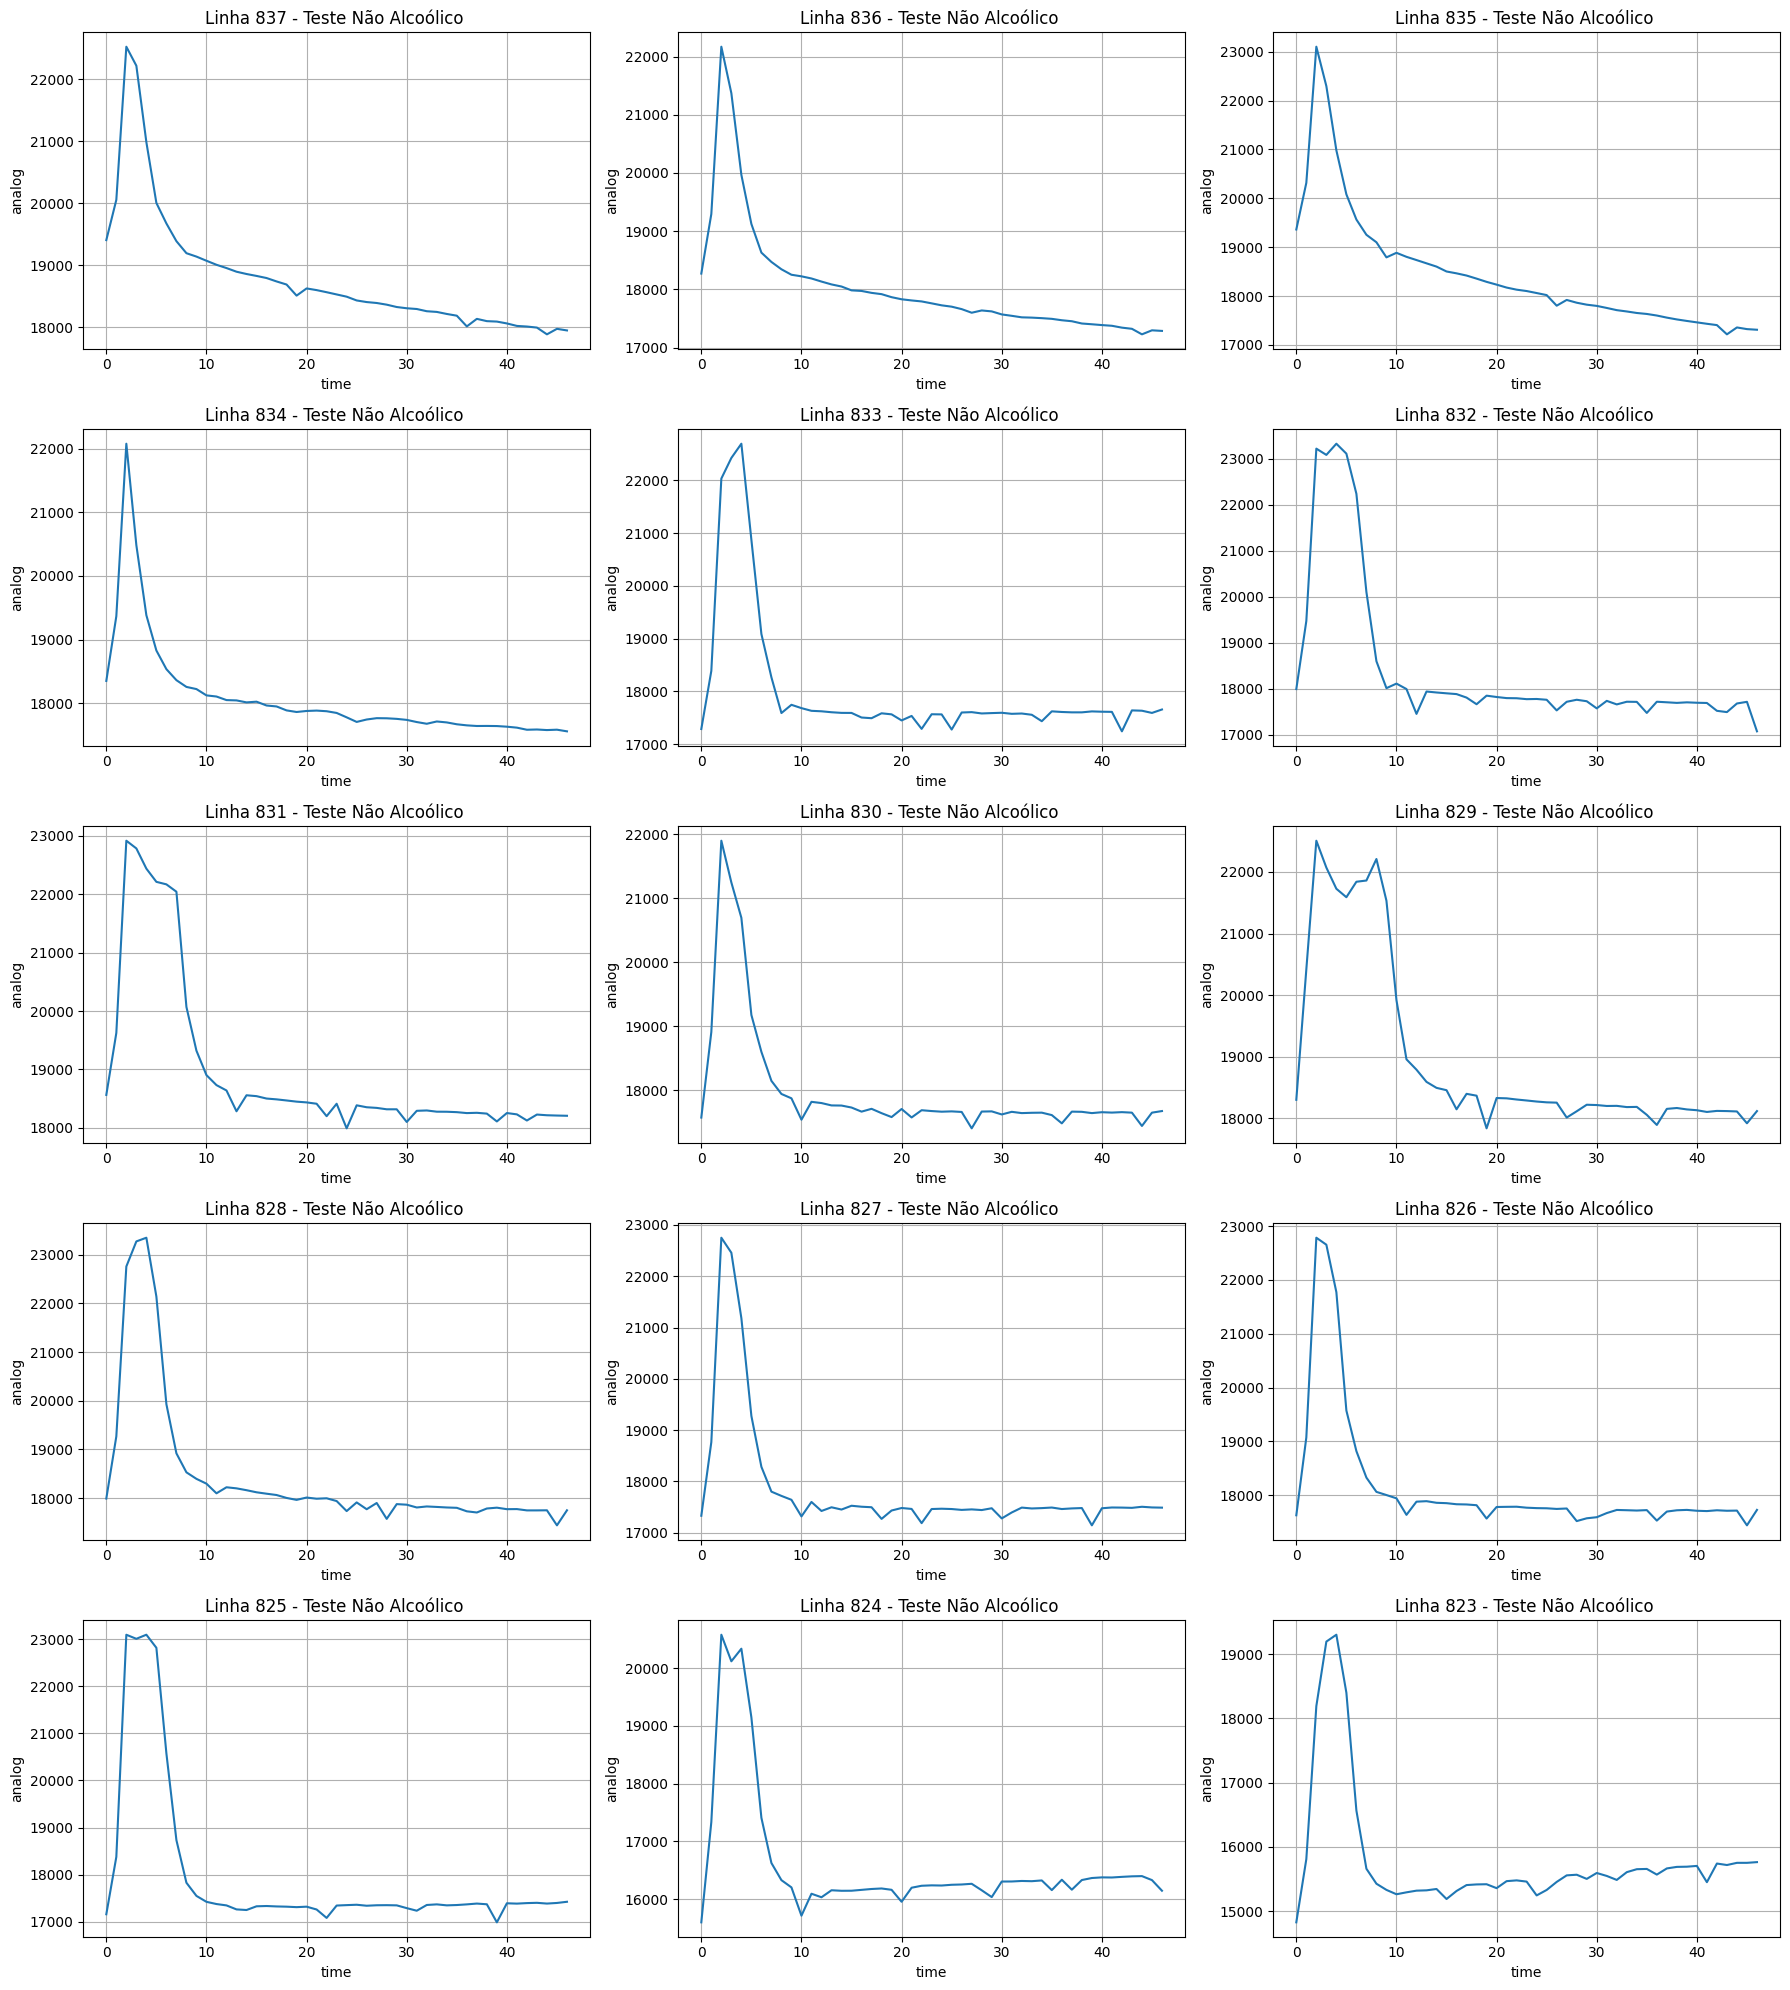

In [12]:
import math

def plotTables(df, limit=None):
    count   = len(df) if limit is None else min(limit, len(df))
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))
    
    for idx, (i, row) in enumerate(df.iterrows()):
        if idx >= count:
            break
        
        plt.subplot(numRows, numCols, idx+1)
        plt.plot(row.data)
        title  = f'Linha {i+2} - Teste {"Alcoólico" if row["alcohol"] else "Não Alcoólico"}'
        status = f''
        
        plt.title(f'{title} {status}')
        plt.grid(), plt.xlabel('time'), plt.ylabel('analog')
    
    plt.tight_layout()
    plt.show()


plotTables(df.iloc[::-1], limit=15)

# ENGENHARIA DE ATRIBUTOS

In [13]:
from scipy.stats import skew, kurtosis

In [14]:
df['mean']   = [np.mean(data) for data in df.data]
df['std']    = [np.std(data, ddof=1) for data in df.data]
df['min']    = [np.min(data) for data in df.data]
df['max']    = [np.max(data) for data in df.data]
df['first']  = [data[0] for data in df.data]
df['last']   = [data[-1] for data in df.data]
df['median'] = [np.median(data) for data in df.data]

df['amplitude'] = [np.max(data) - np.min(data) for data in df.data]
df['rise']      = [data[0]  - np.max(data) for data in df.data]
df['decay']     = [data[0] - np.min(data) for data in df.data]
df['reldecay']  = [(np.max(data) - np.min(data))/np.mean(data) for data in df.data]
df['residual']  = [data[-1] - data[0] for data in df.data]

df['mean_diff']   = [np.mean(np.gradient(data)) for data in df.data]
df['std_diff']    = [np.std(np.gradient(data), ddof=1) for data in df.data]
df['min_diff']    = [np.min(np.gradient(data)) for data in df.data]
df['max_diff']    = [np.max(np.gradient(data)) for data in df.data]
df['first_diff']  = [np.gradient(data)[0] for data in df.data]
df['last_diff']   = [np.gradient(data)[-1] for data in df.data]
df['median_diff'] = [np.median(np.gradient(data)) for data in df.data]

df['time_peak'] = [np.argmax(data) for data in df.data]
df['time_low']  = [np.argmin(data) for data in df.data]
df['skew']      = [skew(data) for data in df.data]   # Assimetria
df['kurt']      = [kurtosis(data) for data in df.data] # Curtose
df['slope_ratio'] = df['min_diff'] / (df['max'] - df['min'])
df['decayed'] = [(data[0] - np.min(data) > 1500) for data in df.data]
df.head(3)

,data,alcohol,mean,std,min,max,first,last,median,amplitude,rise,decay,reldecay,residual,mean_diff,std_diff,min_diff,max_diff,first_diff,last_diff,median_diff,time_peak,time_low,skew,kurt,slope_ratio,decayed
0,"[23534, 24013, 26216, 26172, 26108, 25037, 240...",False,23557.723404,750.506487,23250,26216,23534,23275,23281.0,2966,-2682,284,0.125904,-259,-0.382979,334.276298,-1006.5,1341.0,479.0,3.0,-2.0,2,34,2.908454,7.086787,-0.339346,False
1,"[23797, 24164, 26134, 26143, 26142, 26120, 253...",False,23877.446809,756.473851,23536,26143,23797,23596,23585.0,2607,-2346,261,0.109183,-201,-0.361702,297.088420,-858.5,1168.5,367.0,1.0,0.5,3,37,2.459624,4.403464,-0.329306,False
2,"[23899, 24905, 26249, 26359, 26335, 26225, 254...",False,24055.574468,757.619921,23695,26359,23899,23801,23765.0,2664,-2460,204,0.110744,-98,8.680851,312.737500,-862.0,1175.0,1006.0,6.0,2.0,3,32,2.384043,4.089210,-0.323574,False


# COMPONENTES PCA

In [15]:
from sklearn.decomposition import PCA as getPCA
from sklearn.preprocessing import StandardScaler

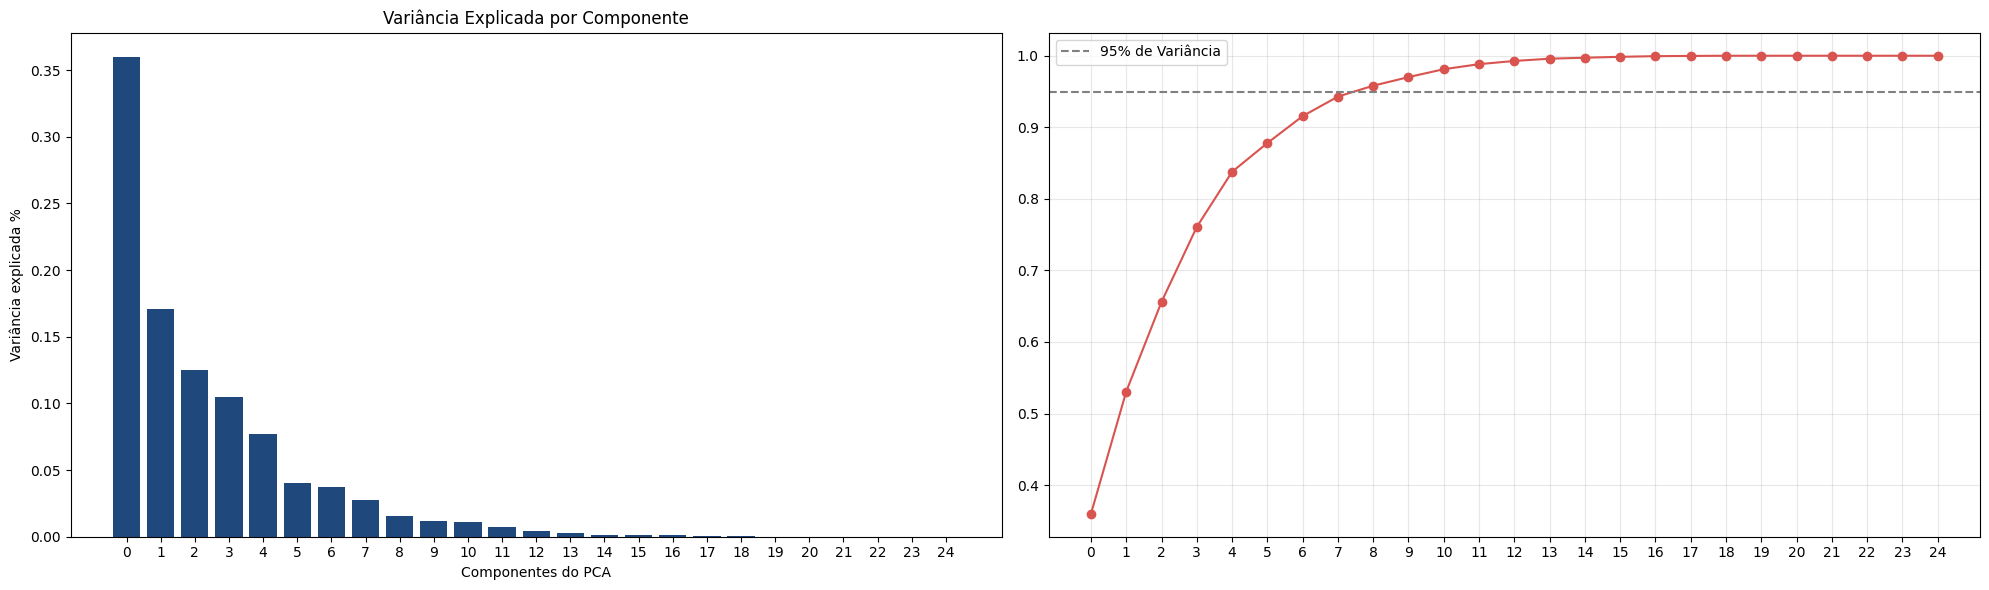

In [16]:
class PCA:
    def __init__(self, xData):
        self.xData  = xData
        self.scaler = StandardScaler()
        self.xData  = self.scaler.fit_transform(self.xData)

        pca = getPCA()
        pca.fit(self.xData) 

        self.pca_exp    = pca.explained_variance_ratio_
        self.pca_sum    = np.cumsum(self.pca_exp)
        self.components = np.arange(len(self.pca_exp))

    def plot(self, target=0.90):
        plt.figure(figsize=(20, 6))
        plt.subplot(1, 2, 1)
        plt.bar(self.components, self.pca_exp, color='#1f497d')
        plt.title('Variância Explicada por Componente')
        plt.xlabel('Componentes do PCA')
        plt.ylabel('Variância explicada %')
        plt.xticks(self.components)

        plt.subplot(1, 2, 2)
        plt.plot(self.components, self.pca_sum, marker='o', color='#d9534f', linestyle='-')
        plt.axhline(y=target, color='gray', linestyle='--', label=f'{target*100:.0f}% de Variância')
        plt.legend()
        plt.xticks(self.components)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


xData = df.drop(columns=[TARGET, 'data'])
pca = PCA(xData)
pca.plot(0.95)

# SALVANDO O MODELO

In [17]:
df.to_csv('../../Dataset/model.csv', index=None)